# ML Training Notebook for Mueller Matrix Physical Realizability Prediction
# With ONNX Export for MATLAB Compatibility

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import sys
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# For deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# For ONNX export
import onnx
try:
    import onnxruntime as ort
    ONNX_RUNTIME_AVAILABLE = True
except ImportError:
    ONNX_RUNTIME_AVAILABLE = False
    print("Warning: onnxruntime not available. ONNX models will be exported but not verified.")
    print("Install with: pip install onnxruntime")

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Add the parent directory to the path to access the utils module
sys.path.append('..')
from src.utils.file_paths import file_paths, TISSUE_DIMENSIONS
from src.utils.visualisation import plot_and_save_confusion_matrix

# Make sure results dir exists
resultspath = file_paths.model_save_path.parent / 'results'
resultspath.mkdir(parents=True, exist_ok=True)

# ONNX export directory
onnx_path = file_paths.model_save_path / 'onnx'
onnx_path.mkdir(parents=True, exist_ok=True)

labels = ['Not PR', 'PR']


In [2]:
# Set display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1. Load the Prepared Data

In [3]:
# 1.1 Brain (as you already have)
X_brain_full = np.load(file_paths.brain_processed_path / 'merged_all_X.npy')
y_brain      = np.load(file_paths.brain_processed_path / 'merged_all_y.npy')
# use only first 12 MM elements
X_brain = X_brain_full[..., :12]

# 1.2 Cervix
X_cervix_full = np.load(file_paths.cervix_processed_path / 'merged_all_X.npy')
y_cervix      = np.load(file_paths.cervix_processed_path / 'merged_all_y.npy')
X_cervix = X_cervix_full[..., :12]

# 1.3 AFMMM
X_afmmm_full = np.load(file_paths.afmmm_processed_path  / 'merged_all_X.npy')
y_afmmm      = np.load(file_paths.afmmm_processed_path  / 'merged_all_y.npy')
X_afmmm = X_afmmm_full[..., :12]

# Print shapes for sanity
for name, X, y in [
    ('brain', X_brain, y_brain),
    ('cervix', X_cervix, y_cervix),
    ('afmmm', X_afmmm, y_afmmm)
]:
    print(f"{name:6s} → X: {X.shape},   y: {y.shape}")


brain  → X: (31, 388, 516, 12),   y: (31, 388, 516)
cervix → X: (19, 600, 800, 12),   y: (19, 600, 800)
afmmm  → X: (47, 500, 500, 12),   y: (47, 500, 500)


## 2. Prepare Data for Training

In [4]:
# Flatten each to (n_samples * H * W, 12) and (n_samples * H * W,)
def flatten(X, y):
    ns, H, W, F = X.shape
    return X.reshape(-1, F), y.reshape(-1)

Xb_flat, yb_flat = flatten(X_brain, y_brain)
Xc_flat, yc_flat = flatten(X_cervix, y_cervix)
Xa_flat, ya_flat = flatten(X_afmmm, y_afmmm)

# Concatenate across all pixels
X_flat = np.vstack([Xb_flat, Xc_flat, Xa_flat])
y_flat = np.concatenate([yb_flat, yc_flat, ya_flat])

print(f"After merge → X_flat: {X_flat.shape}, y_flat: {y_flat.shape}")


After merge → X_flat: (27076448, 12), y_flat: (27076448,)


## 3. Explore Data Balance

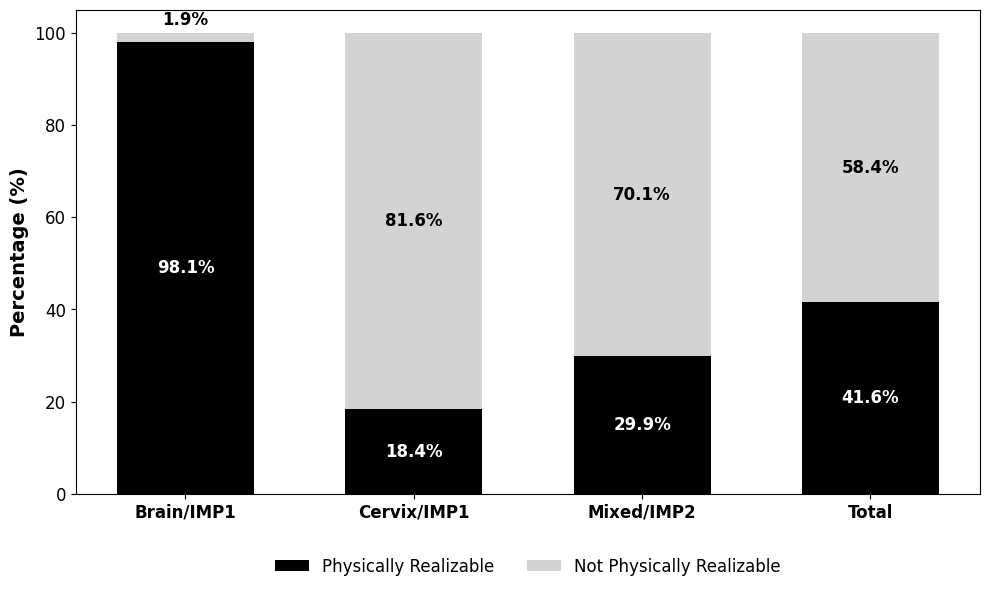

Brain/IMP1   → 6,085,592 PR pixels (98.1%)
Cervix/IMP1  → 1,676,940 PR pixels (18.4%)
Mixed/IMP2   → 3,514,706 PR pixels (29.9%)
Total        → 11,277,238 PR pixels (41.6%)



In [5]:
import matplotlib.pyplot as plt

# Get flat counts
def get_class_distribution(y):
    y_flat = y.reshape(-1)
    values, counts = np.unique(y_flat, return_counts=True)
    dist = dict(zip(values, counts))
    total = sum(counts)
    pct_0 = dist.get(0, 0) / total * 100
    pct_1 = dist.get(1, 0) / total * 100
    return pct_0, pct_1, total

# Get per-tissue distributions
brain_0, brain_1, brain_total = get_class_distribution(y_brain)
cervix_0, cervix_1, cervix_total = get_class_distribution(y_cervix)
afmmm_0, afmmm_1, afmmm_total = get_class_distribution(y_afmmm)

# Compute totals
total_0 = (brain_0 * brain_total + cervix_0 * cervix_total + afmmm_0 * afmmm_total) / (brain_total + cervix_total + afmmm_total)
total_1 = (brain_1 * brain_total + cervix_1 * cervix_total + afmmm_1 * afmmm_total) / (brain_total + cervix_total + afmmm_total)

# Data
data_labels = ['Brain/IMP1', 'Cervix/IMP1', 'Mixed/IMP2', 'Total']
pct_realizable = [brain_1, cervix_1, afmmm_1, total_1]
pct_not_realizable = [brain_0, cervix_0, afmmm_0, total_0]

# Plot
x = np.arange(len(data_labels))
width = 0.6

plt.figure(figsize=(10, 6))

# Draw bars with new colors
bars_realizable = plt.bar(
    x,
    pct_realizable,
    width,
    label='Physically Realizable',
    color='black'
)

bars_not_realizable = plt.bar(
    x,
    pct_not_realizable,
    width,
    bottom=pct_realizable,
    label='Not Physically Realizable',
    color='#d3d3d3'  # light gray
)

# Labels
plt.ylabel('Percentage (%)', fontsize=14, fontweight='bold')
plt.title('', fontsize=16, fontweight='bold')
plt.xticks(x, data_labels, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)
plt.grid(False)

threshold = 5  # % below which we push the label outside

for i in range(len(data_labels)):
    # Realizable segment
    h1 = pct_realizable[i]
    x0 = x[i]
    # if segment is small, draw above; else draw in the center
    if h1 < threshold:
        y1 = h1 + pct_not_realizable[i] * 0.02  # a little above the top
        va1 = 'bottom'
        c1 = 'black'
    else:
        y1 = h1 / 2
        va1 = 'center'
        c1 = 'white'
    plt.text(
        x0, y1,
        f'{h1:.1f}%',
        ha='center', va=va1,
        fontsize=12, fontweight='bold',
        color=c1
    )

    # Not‐realizable segment
    h2 = pct_not_realizable[i]
    bottom2 = pct_realizable[i]
    if h2 < threshold:
        y2 = bottom2 + h2 + total_1 * 0.02  # a little above full stack
        va2 = 'bottom'
    else:
        y2 = bottom2 + h2 / 2
        va2 = 'center'
    plt.text(
        x0, y2,
        f'{h2:.1f}%',
        ha='center', va=va2,
        fontsize=12, fontweight='bold',
        color='black'
    )

plt.ylim(0, 105)
plt.legend(
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()

# Compute PR pixel counts
brain_pr_count  = int(brain_1/100 * brain_total)
cervix_pr_count = int(cervix_1/100 * cervix_total)
afmmm_pr_count  = int(afmmm_1/100 * afmmm_total)
total_pixels    = brain_total + cervix_total + afmmm_total
total_pr_count  = brain_pr_count + cervix_pr_count + afmmm_pr_count
total_pr_pct    = (total_pr_count / total_pixels) * 100

# Print them
print(f"Brain/IMP1   → {brain_pr_count:,} PR pixels ({brain_1:.1f}%)")
print(f"Cervix/IMP1  → {cervix_pr_count:,} PR pixels ({cervix_1:.1f}%)")
print(f"Mixed/IMP2   → {afmmm_pr_count:,} PR pixels ({afmmm_1:.1f}%)")
print(f"Total        → {total_pr_count:,} PR pixels ({total_pr_pct:.1f}%)\n")


## 4. Split Data for Training, Validation, and Testing

Overall class distribution:
Class 0.0: 15799210 (58.35%)
Class 1.0: 11277238 (41.65%)


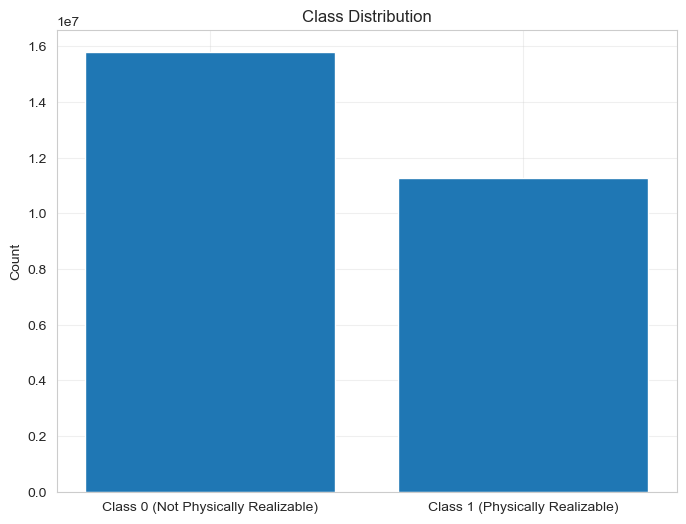

In [19]:

# Check class balance before splitting
unique_values, counts = np.unique(y_flat, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("Overall class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat) * 100:.2f}%)")

plt.figure(figsize=(8, 6))
plt.bar(['Class 0 (Not Physically Realizable)', 'Class 1 (Physically Realizable)'], 
        [class_distribution.get(0, 0), class_distribution.get(1, 0)])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()


In [20]:
# Sample only 10% of the data to make training more manageable
# Subsample data (10% of total) with stratification to maintain class distribution

# Create mask for 0 and 1 classes
mask_0 = (y_flat == 0)
mask_1 = (y_flat == 1)

# Get indices for each class
indices_0 = np.where(mask_0)[0]
indices_1 = np.where(mask_1)[0]

# Select 10% from each class
sample_size_0 = len(indices_0) // 10
sample_size_1 = len(indices_1) // 10

# Randomly sample indices
np.random.seed(42)
sampled_indices_0 = np.random.choice(indices_0, size=sample_size_0, replace=False)
sampled_indices_1 = np.random.choice(indices_1, size=sample_size_1, replace=False)

# Combine indices
sampled_indices = np.concatenate([sampled_indices_0, sampled_indices_1])

# Shuffle the combined indices
np.random.shuffle(sampled_indices)

# Subset the data
X_flat_sampled = X_flat[sampled_indices]
y_flat_sampled = y_flat[sampled_indices]

print(f"Original data size: {len(X_flat):,} samples")
print(f"Sampled data size: {len(X_flat_sampled):,} samples ({len(X_flat_sampled)/len(X_flat)*100:.1f}% of original)")

# Check class distribution after sampling
unique_values, counts = np.unique(y_flat_sampled, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("\nSampled data class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat_sampled) * 100:.2f}%)")


Original data size: 27,076,448 samples
Sampled data size: 2,707,644 samples (10.0% of original)

Sampled data class distribution:
Class 0.0: 1579921 (58.35%)
Class 1.0: 1127723 (41.65%)


In [21]:
# Split the sampled data into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_flat_sampled, y_flat_sampled, test_size=0.2, random_state=42, stratify=y_flat_sampled
)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Check class distribution in each split
for name, y_data in [('Training', y_train), ('Validation', y_val), ('Testing', y_test)]:
    unique_values, counts = np.unique(y_data, return_counts=True)
    class_dist = dict(zip(unique_values, counts))
    print(f"\n{name} set class distribution:")
    for value, count in class_dist.items():
        print(f"Class {value}: {count} ({count / len(y_data) * 100:.2f}%)")



X_train shape: (1624586, 12), y_train shape: (1624586,)
X_val shape: (541529, 12), y_val shape: (541529,)
X_test shape: (541529, 12), y_test shape: (541529,)

Training set class distribution:
Class 0.0: 947953 (58.35%)
Class 1.0: 676633 (41.65%)

Validation set class distribution:
Class 0.0: 315984 (58.35%)
Class 1.0: 225545 (41.65%)

Testing set class distribution:
Class 0.0: 315984 (58.35%)
Class 1.0: 225545 (41.65%)


## 5. Per-pixel classification with an MLP

In [22]:

# Data loaders
train_dataset_cls = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32),
)
val_dataset_cls = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32),
)
test_dataset_cls = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32),
)

# Large batches are fine for tabular data
batch_size_cls   = 8_192
train_loader_cls = DataLoader(train_dataset_cls, batch_size=batch_size_cls, shuffle=True)
val_loader_cls   = DataLoader(val_dataset_cls,   batch_size=batch_size_cls)
test_loader_cls  = DataLoader(test_dataset_cls,  batch_size=batch_size_cls)


In [23]:
class PixelMLP(nn.Module):
    def __init__(self, in_features: int = 12, hidden_sizes=(128, 64, 32)):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # single-logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)                 # raw logits (no sigmoid!)

clf_model = PixelMLP().to(device)


In [24]:
# positives ≈ 91 %  → weight minority 0-class higher
pos_fraction_cls = y_train.mean()
neg_fraction_cls = 1.0 - pos_fraction_cls
pos_weight_val   = neg_fraction_cls / pos_fraction_cls
criterion_cls    = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_val], device=device)
)
print(f"MLP pos_weight = {pos_weight_val:.2f}")

optimizer_cls = optim.Adam(clf_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_cls = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls, mode="min", factor=0.1, patience=3, verbose=True
)


MLP pos_weight = 1.40


/Users/chaechae/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [25]:
def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(train):
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            if train:
                optimizer_cls.zero_grad()

            logits = model(data)
            loss   = criterion_cls(logits, target)

            if train:
                loss.backward()
                optimizer_cls.step()

            total_loss += loss.item() * data.size(0)

            probs = torch.sigmoid(logits)
            y_true.append(target.cpu().numpy())
            y_pred.append((probs > 0.5).float().cpu().numpy())

    y_true = np.concatenate(y_true).ravel()
    y_pred = np.concatenate(y_pred).ravel()

    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return avg_loss, acc, prec, rec, f1


In [26]:
best_val = float("inf")
epochs_cls = 25
for epoch in range(1, epochs_cls + 1):
    tr_loss, tr_acc, _, _, _ = run_epoch(clf_model, train_loader_cls, train=True)
    vl_loss, vl_acc, vl_prec, vl_rec, vl_f1 = run_epoch(clf_model, val_loader_cls, train=False)
    scheduler_cls.step(vl_loss)

    print(f"[MLP Epoch {epoch:02d}/{epochs_cls}] "
          f"train loss {tr_loss:.4f} • val loss {vl_loss:.4f} "
          f"• val F1 {vl_f1:.4f}")

    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(clf_model.state_dict(), file_paths.model_save_path / "best_pixel_mlp.pth")


[MLP Epoch 01/25] train loss 0.2244 • val loss 0.1018 • val F1 0.9679
[MLP Epoch 02/25] train loss 0.1077 • val loss 0.0825 • val F1 0.9722
[MLP Epoch 03/25] train loss 0.0943 • val loss 0.0803 • val F1 0.9711
[MLP Epoch 04/25] train loss 0.0885 • val loss 0.0752 • val F1 0.9734
[MLP Epoch 05/25] train loss 0.0855 • val loss 0.0743 • val F1 0.9744
[MLP Epoch 06/25] train loss 0.0827 • val loss 0.0696 • val F1 0.9754
[MLP Epoch 07/25] train loss 0.0809 • val loss 0.0695 • val F1 0.9746
[MLP Epoch 08/25] train loss 0.0798 • val loss 0.0673 • val F1 0.9759
[MLP Epoch 09/25] train loss 0.0781 • val loss 0.0671 • val F1 0.9758
[MLP Epoch 10/25] train loss 0.0773 • val loss 0.0650 • val F1 0.9764
[MLP Epoch 11/25] train loss 0.0756 • val loss 0.0650 • val F1 0.9760
[MLP Epoch 12/25] train loss 0.0760 • val loss 0.0641 • val F1 0.9760
[MLP Epoch 13/25] train loss 0.0746 • val loss 0.0653 • val F1 0.9760
[MLP Epoch 14/25] train loss 0.0739 • val loss 0.0655 • val F1 0.9741
[MLP Epoch 15/25] tr

In [27]:
y_true_list, y_pred_list, y_probs_list = [], [], []
clf_model.eval()
with torch.no_grad():
    for data, target in test_loader_cls:
        data = data.to(device)
        logits = clf_model(data)
        probs  = torch.sigmoid(logits).cpu().numpy().ravel()
        preds  = (probs > 0.5).astype(int)
        y_pred_list.append(preds)
        y_probs_list.append(probs)
        y_true_list.append(target.cpu().numpy().ravel())

y_true_all = np.concatenate(y_true_list)
y_pred_all = np.concatenate(y_pred_list)
y_probs_all = np.concatenate(y_probs_list)

# Compute metrics
mlp_results = {
    'model':    'PixelMLP',
    'accuracy': accuracy_score(y_true_all, y_pred_all),
    'precision': precision_score(y_true_all, y_pred_all),
    'recall':    recall_score(y_true_all, y_pred_all),
    'f1':        f1_score(y_true_all, y_pred_all),
    'roc_auc':   roc_auc_score(y_true_all, y_probs_all),
}

# Save to CSV
pd.DataFrame([mlp_results]).to_csv(resultspath / 'pixel_mlp_metrics.csv', index=False)
print("Saved MLP metrics →", resultspath / 'pixel_mlp_metrics.csv')

# Plot confusion matrix
plot_and_save_confusion_matrix(
    y_true=y_test.ravel(),
    y_pred=y_pred_all,
    labels=labels,
    title="Pixel-MLP Confusion Matrix",
    save_path=resultspath / 'mlp_confusion_matrix.png'
)


Saved MLP metrics → /Users/chaechae/Desktop/EP_Code/partialPr/results/pixel_mlp_metrics.csv


## 6. Export MLP to ONNX

In [28]:

def export_mlp_to_onnx(model, save_path, input_size=12):
    """Export PyTorch MLP model to ONNX format"""
    model.eval()
    model.to('cpu')  # ONNX export works best on CPU
    
    # Create dummy input
    dummy_input = torch.randn(1, input_size, dtype=torch.float32)
    
    # Export to ONNX
    torch.onnx.export(
        model,
        dummy_input,
        save_path,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )
    
    # Verify the model
    onnx_model = onnx.load(save_path)
    onnx.checker.check_model(onnx_model)
    
    print(f"✓ MLP exported to ONNX: {save_path}")
    
    # Test the ONNX model
    ort_session = ort.InferenceSession(save_path)
    ort_inputs = {ort_session.get_inputs()[0].name: dummy_input.numpy()}
    ort_outs = ort_session.run(None, ort_inputs)
    
    print(f"✓ ONNX model verified - output shape: {ort_outs[0].shape}")
    
    return save_path

# Export MLP
mlp_onnx_path = onnx_path / 'pixel_mlp.onnx'
export_mlp_to_onnx(clf_model, mlp_onnx_path)


✓ MLP exported to ONNX: /Users/chaechae/Desktop/EP_Code/partialPr/model/onnx/pixel_mlp.onnx
✓ ONNX model verified - output shape: (1, 1)


PosixPath('/Users/chaechae/Desktop/EP_Code/partialPr/model/onnx/pixel_mlp.onnx')

## 7. XGBoost Gradient-Boosted Trees

In [29]:

import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train, weight=np.where(y_train == 0, pos_weight_val, 1.0))
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = dict(
    objective   = "binary:logistic",
    eval_metric = "logloss",
    eta         = 0.05,
    max_depth   = 7,
    subsample   = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight_val,
    nthread     = -1,
    seed        = 42,
)

print("Training XGBoost...")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round      = 2000,
    evals                = [(dval, "val")],
    early_stopping_rounds= 50,
    verbose_eval         = 100,
)

print("\n  XGBoost test metrics")
y_proba_xgb = bst.predict(dtest)
y_hat_xgb = (y_proba_xgb > 0.5).astype(int)

print(f"accuracy  {accuracy_score(y_test, y_hat_xgb):.4f}")
print(f"precision {precision_score(y_test, y_hat_xgb):.4f}")
print(f"recall    {recall_score(y_test, y_hat_xgb):.4f}")
print(f"F1        {f1_score(y_test, y_hat_xgb):.4f}")

# Save model
bst.save_model(str(file_paths.model_save_path / "pixel_xgb.json"))

# Save metrics
xgb_results = {
    'model':    'XGBoost',
    'accuracy':   accuracy_score(y_test, y_hat_xgb),
    'precision':  precision_score(y_test, y_hat_xgb),
    'recall':     recall_score(y_test, y_hat_xgb),
    'f1':         f1_score(y_test, y_hat_xgb),
    'roc_auc':    roc_auc_score(y_test, y_proba_xgb),
}

pd.DataFrame([xgb_results]).to_csv(resultspath / 'xgb_metrics.csv', index=False)
print("Saved XGBoost metrics →", resultspath / 'xgb_metrics.csv')

# Confusion matrix
plot_and_save_confusion_matrix(
    y_true=y_test.ravel(),
    y_pred=y_hat_xgb,
    labels=labels,
    title="XGBoost Confusion Matrix",
    save_path=resultspath / 'xgb_confusion_matrix.png'
)


Training XGBoost...
[0]	val-logloss:0.63538
[100]	val-logloss:0.06984
[200]	val-logloss:0.05733
[300]	val-logloss:0.05268
[400]	val-logloss:0.05049
[500]	val-logloss:0.04931
[600]	val-logloss:0.04851
[700]	val-logloss:0.04793
[800]	val-logloss:0.04748
[900]	val-logloss:0.04718
[1000]	val-logloss:0.04687
[1100]	val-logloss:0.04668
[1200]	val-logloss:0.04651
[1300]	val-logloss:0.04638
[1400]	val-logloss:0.04629
[1500]	val-logloss:0.04622
[1600]	val-logloss:0.04618
[1700]	val-logloss:0.04615
[1800]	val-logloss:0.04612
[1900]	val-logloss:0.04610
[1984]	val-logloss:0.04611

  XGBoost test metrics
accuracy  0.9815
precision 0.9852
recall    0.9702
F1        0.9776
Saved XGBoost metrics → /Users/chaechae/Desktop/EP_Code/partialPr/results/xgb_metrics.csv


## 8. Export XGBoost to ONNX

In [38]:
# add this for onnxmltools (XGBoost export)
from onnxmltools.convert.common.data_types import FloatTensorType as OmlFloatTensorType

def export_xgboost_to_onnx(booster, save_path, n_features=12):
    # Use the onnxmltools data type here (not skl2onnx)
    initial_type = [('float_input', OmlFloatTensorType([None, n_features]))]

    from onnxmltools.convert import convert_xgboost
    onnx_model = convert_xgboost(
        booster,
        initial_types=initial_type,
        target_opset=11
    )

    with open(save_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

    import onnx
    onnx_model_check = onnx.load(save_path)
    onnx.checker.check_model(onnx_model_check)
    print(f"XGBoost exported to ONNX: {save_path}")
    print("ONNX model verified")
    return save_path

# Export XGBoost
xgb_onnx_path = onnx_path / 'pixel_xgb.onnx'
export_xgboost_to_onnx(bst, xgb_onnx_path)


XGBoost exported to ONNX: /Users/chaechae/Desktop/EP_Code/partialPr/model/onnx/pixel_xgb.onnx
ONNX model verified


PosixPath('/Users/chaechae/Desktop/EP_Code/partialPr/model/onnx/pixel_xgb.onnx')

## 9. CatBoost Classifier

In [39]:

from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train, weight=np.where(y_train == 0, pos_weight_val, 1.0))
val_pool   = Pool(X_val,   y_val)

cat = CatBoostClassifier(
    loss_function       = "Logloss",
    depth               = 8,
    learning_rate       = 0.05,
    iterations          = 2000,
    l2_leaf_reg         = 3.0,
    random_seed         = 42,
    eval_metric         = "Logloss",
    verbose             = 200,
    early_stopping_rounds = 100,
    class_weights       = [pos_weight_val, 1.0],
)

print("  Training CatBoost …")
cat.fit(train_pool, eval_set=val_pool)

print("\n  CatBoost test metrics")
y_proba_cb = cat.predict_proba(X_test)[:, 1]
y_pred_cb = (y_proba_cb > 0.5).astype(int)

print(f"accuracy  {accuracy_score(y_test, y_pred_cb):.4f}")
print(f"precision {precision_score(y_test, y_pred_cb):.4f}")
print(f"recall    {recall_score(y_test, y_pred_cb):.4f}")
print(f"F1        {f1_score(y_test, y_pred_cb):.4f}")

# Save model
cat.save_model(file_paths.model_save_path / "pixel_catboost.cbm")

# Save metrics
cb_results = {
    'model':    'CatBoost',
    'accuracy':  accuracy_score(y_test, y_pred_cb),
    'precision': precision_score(y_test, y_pred_cb),
    'recall':    recall_score(y_test, y_pred_cb),
    'f1':        f1_score(y_test, y_pred_cb),
    'roc_auc':   roc_auc_score(y_test, y_proba_cb),
}

pd.DataFrame([cb_results]).to_csv(resultspath / 'catboost_metrics.csv', index=False)
print("Saved CatBoost metrics →", resultspath / 'catboost_metrics.csv')

# Confusion matrix
plot_and_save_confusion_matrix(
    y_true=y_test.ravel(),
    y_pred=y_pred_cb,
    labels=labels,
    title="CatBoost Confusion Matrix",
    save_path=resultspath / 'catboost_confusion_matrix.png'
)


  Training CatBoost …
0:	learn: 0.5590454	test: 0.5605725	best: 0.5605725 (0)	total: 111ms	remaining: 3m 42s
200:	learn: 0.0503182	test: 0.0574003	best: 0.0574003 (200)	total: 8.87s	remaining: 1m 19s
400:	learn: 0.0447305	test: 0.0514598	best: 0.0514598 (400)	total: 17.4s	remaining: 1m 9s
600:	learn: 0.0417994	test: 0.0487101	best: 0.0487101 (600)	total: 26.3s	remaining: 1m 1s
800:	learn: 0.0399201	test: 0.0471400	best: 0.0471400 (800)	total: 34.2s	remaining: 51.1s
1000:	learn: 0.0385391	test: 0.0461737	best: 0.0461737 (1000)	total: 42.1s	remaining: 42s
1200:	learn: 0.0374087	test: 0.0454850	best: 0.0454850 (1200)	total: 50s	remaining: 33.3s
1400:	learn: 0.0363945	test: 0.0449378	best: 0.0449378 (1400)	total: 57.9s	remaining: 24.8s
1600:	learn: 0.0354926	test: 0.0445069	best: 0.0445069 (1600)	total: 1m 5s	remaining: 16.4s
1800:	learn: 0.0347146	test: 0.0441584	best: 0.0441584 (1800)	total: 1m 13s	remaining: 8.14s
1999:	learn: 0.0340359	test: 0.0438819	best: 0.0438819 (1999)	total: 1m 2

## 10. Export CatBoost to ONNX

In [40]:

def export_catboost_to_onnx(catboost_model, save_path):
    """Export CatBoost model to ONNX format"""
    
    # CatBoost has native ONNX export
    catboost_model.save_model(
        save_path,
        format="onnx",
        export_parameters={
            'onnx_domain': 'ai.catboost',
            'onnx_model_version': 1,
            'onnx_doc_string': 'CatBoost model for Mueller Matrix PR classification',
            'onnx_graph_name': 'CatBoostModel_graph'
        }
    )
    
    print(f"CatBoost exported to ONNX: {save_path}")
    
    # Verify the model
    onnx_model = onnx.load(save_path)
    onnx.checker.check_model(onnx_model)
    print(f"ONNX model verified")
    
    return save_path

# Export CatBoost
catboost_onnx_path = onnx_path / 'pixel_catboost.onnx'
export_catboost_to_onnx(cat, catboost_onnx_path)


CatBoostError: catboost/libs/model/model_export/onnx_helpers.cpp:137: ONNX format does not support floating-point labels

## 11. Create MATLAB Usage Guide

In [ ]:

def create_matlab_usage_guide(onnx_dir):
    """Create a MATLAB script showing how to use the ONNX models"""
    
    matlab_script = """% MATLAB Script for Using ONNX Models
% Mueller Matrix Physical Realizability Classification

%% Load and Use MLP Model
% Load the MLP ONNX model
mlp_net = importONNXNetwork('pixel_mlp.onnx', 'OutputLayerType', 'regression');

% Example: Predict on a single sample (12 features)
sample_input = randn(1, 12, 'single');  % Replace with your actual data
mlp_prediction_logit = predict(mlp_net, sample_input);

% Apply sigmoid to get probability
mlp_probability = 1 ./ (1 + exp(-mlp_prediction_logit));

% Get binary prediction (threshold at 0.5)
mlp_class = mlp_probability > 0.5;

fprintf('MLP Prediction: Class %d (Probability: %.4f)\\n', mlp_class, mlp_probability);

%% Load and Use XGBoost Model
% For XGBoost, we need to use ONNX Runtime
% First, make sure you have ONNX Runtime installed for MATLAB

% Load the XGBoost model using ONNX Runtime
% Note: This requires the Deep Learning Toolbox and ONNX support

% Example using importONNXFunction (MATLAB R2021a+)
xgb_fcn = importONNXFunction('pixel_xgb.onnx', 'xgb_predict');

% Predict on sample data
sample_input_xgb = randn(1, 12, 'single');
xgb_output = xgb_fcn(sample_input_xgb);

% XGBoost outputs probability directly
xgb_probability = xgb_output;
xgb_class = xgb_probability > 0.5;

fprintf('XGBoost Prediction: Class %d (Probability: %.4f)\\n', xgb_class, xgb_probability);

%% Load and Use CatBoost Model
% Similar to XGBoost
catboost_fcn = importONNXFunction('pixel_catboost.onnx', 'catboost_predict');

% Predict on sample data
sample_input_cb = randn(1, 12, 'single');
cb_output = catboost_fcn(sample_input_cb);

% CatBoost outputs probability directly
cb_probability = cb_output;
cb_class = cb_probability > 0.5;

fprintf('CatBoost Prediction: Class %d (Probability: %.4f)\\n', cb_class, cb_probability);

%% Batch Prediction Example
% Process multiple samples at once

% Create batch of samples (N x 12)
N = 100;
batch_data = randn(N, 12, 'single');

% MLP batch prediction
mlp_batch_logits = predict(mlp_net, batch_data);
mlp_batch_probs = 1 ./ (1 + exp(-mlp_batch_logits));
mlp_batch_classes = mlp_batch_probs > 0.5;

fprintf('\\nProcessed %d samples with MLP\\n', N);
fprintf('Class 0 (Not PR): %d samples\\n', sum(~mlp_batch_classes));
fprintf('Class 1 (PR): %d samples\\n', sum(mlp_batch_classes));

%% Load Mueller Matrix Data and Predict
% Example: Load your Mueller matrix data
% Assuming you have a matrix of shape [Height, Width, 12]

% Example data loading (replace with your actual data)
% mueller_data = load('your_mueller_matrix.mat');
% X_mueller = mueller_data.X;  % Should be [H, W, 12]

% Reshape to [H*W, 12] for pixel-wise prediction
% [H, W, C] = size(X_mueller);
% X_flat = reshape(X_mueller, [H*W, 12]);

% Predict on all pixels
% predictions = predict(mlp_net, X_flat);
% probabilities = 1 ./ (1 + exp(-predictions));
% classes = probabilities > 0.5;

% Reshape back to image
% class_map = reshape(classes, [H, W]);
% prob_map = reshape(probabilities, [H, W]);

% Visualize results
% figure;
% subplot(1,2,1);
% imagesc(class_map);
% colorbar;
% title('Physical Realizability Classification');
% xlabel('X'); ylabel('Y');
% 
% subplot(1,2,2);
% imagesc(prob_map);
% colorbar;
% title('PR Probability Map');
% xlabel('X'); ylabel('Y');

%% Notes:
% 1. Input data should be single precision (float32)
% 2. Input shape for single sample: [1, 12]
% 3. Input shape for batch: [N, 12]
% 4. MLP outputs logits - apply sigmoid for probabilities
% 5. XGBoost and CatBoost output probabilities directly
% 6. Threshold at 0.5 for binary classification
% 7. Class 0 = Not Physically Realizable
% 8. Class 1 = Physically Realizable

%% Model Comparison Function
function compare_models(input_data)
    % Load all three models
    mlp_net = importONNXNetwork('pixel_mlp.onnx', 'OutputLayerType', 'regression');
    xgb_fcn = importONNXFunction('pixel_xgb.onnx', 'xgb_predict');
    cb_fcn = importONNXFunction('pixel_catboost.onnx', 'catboost_predict');
    
    % Predict with all models
    mlp_logit = predict(mlp_net, input_data);
    mlp_prob = 1 ./ (1 + exp(-mlp_logit));
    
    xgb_prob = xgb_fcn(input_data);
    cb_prob = cb_fcn(input_data);
    
    % Display results
    fprintf('\\nModel Comparison:\\n');
    fprintf('MLP Probability:      %.4f\\n', mlp_prob);
    fprintf('XGBoost Probability:  %.4f\\n', xgb_prob);
    fprintf('CatBoost Probability: %.4f\\n', cb_prob);
    fprintf('\\nEnsemble (Average):   %.4f\\n', mean([mlp_prob, xgb_prob, cb_prob]));
end
"""
    
    # Save MATLAB script
    matlab_file = onnx_dir / 'use_models_in_matlab.m'
    with open(matlab_file, 'w') as f:
        f.write(matlab_script)
    
    print(f"MATLAB usage guide created: {matlab_file}")
    
    # Create README
    readme_content = """# ONNX Models for MATLAB

This directory contains ONNX models for Mueller Matrix Physical Realizability classification.

## Files

- `pixel_mlp.onnx` - PyTorch MLP model
- `pixel_xgb.onnx` - XGBoost gradient boosting model
- `pixel_catboost.onnx` - CatBoost gradient boosting model
- `use_models_in_matlab.m` - MATLAB script with usage examples

## Requirements

### MATLAB
- MATLAB R2020b or later
- Deep Learning Toolbox
- ONNX support (included in Deep Learning Toolbox)

### Python (for verification)
```bash
pip install onnx onnxruntime numpy
```

## Usage in MATLAB

1. Copy all ONNX files to your MATLAB working directory
2. Run the script:
```matlab
use_models_in_matlab
```

## Input Format

- **Shape**: `[N, 12]` where N is the number of samples
- **Type**: `single` (float32)
- **Features**: 12 Mueller matrix elements

## Output Format

- **MLP**: Raw logits (apply sigmoid for probabilities)
- **XGBoost/CatBoost**: Probabilities directly
- **Classification**: Threshold at 0.5

## Example

```matlab
% Load model
net = importONNXNetwork('pixel_mlp.onnx', 'OutputLayerType', 'regression');

% Prepare input (12 features)
X = randn(1, 12, 'single');

% Predict
logit = predict(net, X);
probability = 1 / (1 + exp(-logit));
class = probability > 0.5;

% class = 0: Not Physically Realizable
% class = 1: Physically Realizable
```

## Model Performance

See the `results/` directory for:
- Confusion matrices
- Performance metrics (accuracy, precision, recall, F1, ROC-AUC)

## Troubleshooting

1. **"importONNXNetwork not found"**: Install Deep Learning Toolbox
2. **Data type errors**: Ensure input is `single` precision
3. **Shape errors**: Input must be `[N, 12]` format

## Python Verification

```python
import onnxruntime as ort
import numpy as np

# Load model
session = ort.InferenceSession('pixel_mlp.onnx')

# Prepare input
X = np.random.randn(1, 12).astype(np.float32)

# Predict
output = session.run(None, {'input': X})
print(f"Output: {output}")
```
"""
    
    readme_file = onnx_dir / 'README.md'
    with open(readme_file, 'w') as f:
        f.write(readme_content)
    
    print(f"README created: {readme_file}")

# Create MATLAB guide
create_matlab_usage_guide(onnx_path)


## 12. Test ONNX Models with Python

In [41]:

def test_onnx_model(onnx_path, test_data, model_name="Model"):
    """Test ONNX model using ONNX Runtime"""
    
    print(f"\n{'='*60}")
    print(f"Testing {model_name}")
    print(f"{'='*60}")
    
    # Create inference session
    session = ort.InferenceSession(str(onnx_path))
    
    # Get input name
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    
    print(f"Input name: {input_name}")
    print(f"Output name: {output_name}")
    print(f"Input shape: {session.get_inputs()[0].shape}")
    print(f"Output shape: {session.get_outputs()[0].shape}")
    
    # Prepare test data
    test_sample = test_data[:5].astype(np.float32)  # Test on 5 samples
    
    # Run inference
    ort_inputs = {input_name: test_sample}
    ort_outputs = session.run([output_name], ort_inputs)
    
    print(f"\nTest predictions (first 5 samples):")
    print(ort_outputs[0][:5])
    
    return ort_outputs[0]

# Test all ONNX models
print("\n" + "="*80)
print("TESTING ONNX MODELS")
print("="*80)

mlp_onnx_outputs = test_onnx_model(
    mlp_onnx_path, 
    X_test, 
    "MLP Model"
)

xgb_onnx_outputs = test_onnx_model(
    xgb_onnx_path, 
    X_test, 
    "XGBoost Model"
)

catboost_onnx_outputs = test_onnx_model(
    catboost_onnx_path, 
    X_test, 
    "CatBoost Model"
)



TESTING ONNX MODELS

Testing MLP Model
Input name: input
Output name: output
Input shape: ['batch_size', 12]
Output shape: ['batch_size', 1]

Test predictions (first 5 samples):
[[ -4.532127]
 [  5.516075]
 [-16.248299]
 [-15.334206]
 [ 13.85648 ]]

Testing XGBoost Model
Input name: float_input
Output name: label
Input shape: [None, 12]
Output shape: [None]

Test predictions (first 5 samples):
[0 1 0 0 1]

Testing CatBoost Model


Fail: [ONNXRuntimeError] : 1 : FAIL : Load model from /Users/chaechae/Desktop/EP_Code/partialPr/model/onnx/pixel_catboost.onnx failed:/Users/runner/work/1/s/onnxruntime/core/graph/model.cc:166 onnxruntime::Model::Model(ModelProto &&, const PathString &, const IOnnxRuntimeOpSchemaRegistryList *, const logging::Logger &, const ModelOptions &) ModelProto does not have a graph.


## 13. Summary and Export Information

In [ ]:

print("\n" + "="*80)
print("EXPORT SUMMARY")
print("="*80)

print(f"\nAll models saved to: {file_paths.model_save_path}")
print(f"ONNX models saved to: {onnx_path}")
print(f"Results saved to: {resultspath}")

print("\nPyTorch Models:")
print(f"   - best_pixel_mlp.pth")

print("\nXGBoost Models:")
print(f"   - pixel_xgb.json")

print("\nCatBoost Models:")
print(f"   - pixel_catboost.cbm")

print("\nONNX Models (MATLAB-compatible):")
print(f"   - pixel_mlp.onnx")
print(f"   - pixel_xgb.onnx")
print(f"   - pixel_catboost.onnx")

print("\nDocumentation:")
print(f"   - README.md")
print(f"   - use_models_in_matlab.m")

print("\nResults:")
print(f"   - pixel_mlp_metrics.csv")
print(f"   - xgb_metrics.csv")
print(f"   - catboost_metrics.csv")
print(f"   - mlp_confusion_matrix.png")
print(f"   - xgb_confusion_matrix.png")
print(f"   - catboost_confusion_matrix.png")

print("\n" + "="*80)
print("MATLAB USAGE INSTRUCTIONS")
print("="*80)

print("""
1. Navigate to the ONNX directory in MATLAB:
   >> cd('path/to/onnx/directory')

2. Run the usage script:
   >> use_models_in_matlab

3. Or load a specific model:
   >> net = importONNXNetwork('pixel_mlp.onnx', 'OutputLayerType', 'regression');
   >> X = randn(1, 12, 'single');  % Your data here
   >> prediction = predict(net, X);

4. For detailed examples, see: use_models_in_matlab.m

Requirements:
- MATLAB R2020b or later
- Deep Learning Toolbox
""")

print("\n" + "="*80)
print("ALL EXPORTS COMPLETE")
print("="*80)